# Analysing `PREFIX.kappa.h5`

This notebook reads the HDF5 file that *anphon* writes with `MODE = kappa`
and rebuilds the thermal conductivity from the mode-resolved data in it:

1. inspect the file and its metadata,
2. plot $\kappa(T)$,
3. compute phonon lifetimes from the linewidths,
4. rebuild $\kappa$ from the mode sum and check it against the value in the file,
5. analyse the mode-resolved $\kappa$: cumulative $\kappa$ versus mean free path and versus frequency.

It needs only NumPy, h5py, and Matplotlib, so it also runs on Google Colab.
The data file is `example/Si/reference/si222.kappa.h5`: silicon in the RTA on a $10\times10\times10$ $q$ mesh,
made with `example/Si/reference/si222_kappa.in` from the force constants of the Si tutorial.
The layout of the file is described in the ALAMODE documentation (*HDF5 files*).

In [1]:
import os
import urllib.request

import h5py
import matplotlib.pyplot as plt
import numpy as np

%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 90

# Use the file of a local ALAMODE checkout if there is one; otherwise (e.g. on Colab) download it.
FNAME = "si222.kappa.h5"
LOCAL = os.path.join("..", "Si", "reference", FNAME)
URL = "https://raw.githubusercontent.com/alamode-code/alamode/2.0dev/example/Si/reference/" + FNAME

if os.path.exists(LOCAL):
    path = LOCAL
else:
    if not os.path.exists(FNAME):
        urllib.request.urlretrieve(URL, FNAME)
    path = FNAME
print("Reading", path)

Reading ../Si/reference/si222.kappa.h5


## 1. What is in the file

The root attributes identify the file; every dataset carries its unit in a `unit` attribute.

In [2]:
f = h5py.File(path, "r")

for key, val in f.attrs.items():
    print(f"{key:22s} {val}")
print()

def show(name, obj):
    if isinstance(obj, h5py.Dataset):
        unit = obj.attrs.get("unit", "")
        print(f"{name:40s} {str(obj.shape):16s} {unit}")

f.visititems(show)

alamode_git_commit     80e3d894bf957fca03fb1a1db7afeb2c47ca34ec-dirty
alamode_version        1.9.9
created_date           2026-Sep-24 03:07:28
format_version         1
schema                 alamode:kappa_result
temperature_resolved   0

kappa/kappa_peierls                      (19, 3, 3)       W/mK
kappa/valid                              (1,)             
metadata/PrimitiveCell/atomic_kinds      (2,)             
metadata/PrimitiveCell/elements          (1,)             
metadata/PrimitiveCell/fractional_coordinate (2, 3)           
metadata/PrimitiveCell/lattice_vector    (3, 3)           bohr
metadata/PrimitiveCell/number_of_atoms   ()               
metadata/PrimitiveCell/number_of_elements ()               
metadata/PrimitiveCell/volume            ()               bohr^3
metadata/classical                       ()               
metadata/fcs_file                        ()               
metadata/ismear                          ()               
metadata/isotope                   

In [3]:
inp = f["metadata/input_variables"].attrs
for key in ["MODE", "FCSFILE", "ISMEAR", "EPSILON", "ISOTOPE", "TMIN", "TMAX", "DT"]:
    print(f"{key:8s} = {inp[key]}")
print()
print("kappa attributes:", dict(f["kappa"].attrs))

MODE     = KAPPA
FCSFILE  = si222_cubic.xml
ISMEAR   = -1
EPSILON  = 10
ISOTOPE  = 1
TMIN     = 100
TMAX     = 1000
DT       = 50

kappa attributes: {'boundary_length': np.float64(0.0), 'formulation': 'velmat_blocktrace_nosym', 'includes_4ph_scattering': np.int32(0), 'includes_boundary_scattering': np.int32(0), 'includes_isotope_scattering': np.int32(1)}


## 2. Thermal conductivity versus temperature

`/kappa/kappa_peierls` has one $3\times3$ tensor per temperature (the content of `PREFIX.kl`).
Silicon is cubic, so the tensor is diagonal and isotropic.

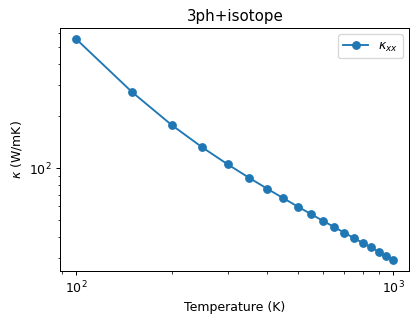

kappa_xx(300 K) = 104.842 W/mK


In [4]:
temps = f["metadata/temperatures"][:]            # K
kappa_file = f["kappa/kappa_peierls"][:]         # (nT, 3, 3), W/mK

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.loglog(temps, kappa_file[:, 0, 0], "o-", label=r"$\kappa_{xx}$")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$\kappa$ (W/mK)")
ax.set_title(f["kappa/kappa_peierls"].attrs["scattering_processes"])
ax.legend()
plt.show()

it300 = int(np.argmin(np.abs(temps - 300.0)))
print(f"kappa_xx({temps[it300]:.0f} K) = {kappa_file[it300, 0, 0]:.3f} W/mK")

## 3. Mode data and lifetimes

`/scattering/3ph` holds the data per mode $(\mathbf{k}, j)$:

* `frequencies` (cm$^{-1}$), shape `(nk_irred, nbranch)`, at the irreducible $k$ points;
* `gamma`, the linewidth $\Gamma$ (half width, cm$^{-1}$), shape `(nk_irred*nbranch, nT)`, row `k*nbranch + j`;
* `velocities` (m/s) and `velocity_diad` (m$^2$/s$^2$) on the **full** mesh.
  The rows `equiv_offsets[k]:equiv_offsets[k+1]` belong to the irreducible point `k`,
  and `equiv_knum` gives their indices on the full mesh.

With `ISOTOPE > 0` (the default for natural Si), `/scattering/isotope/gamma` adds a temperature-independent linewidth.
The scattering rates add up: $\Gamma = \Gamma_\mathrm{3ph} + \Gamma_\mathrm{iso}$.
The file stores the linewidth of each branch as computed; before calculating $\kappa$,
*anphon* averages $\Gamma$ over degenerate branches (frequencies within $10^{-7}$ Ry $\approx 0.011$ cm$^{-1}$),
so we do the same.

The linewidth is stored in cm$^{-1}$; as an angular frequency it is $2\pi c\,\Gamma$, and the lifetime is
$\tau = 1/(2 \cdot 2\pi c\,\Gamma)$. Modes with $\Gamma = 0$ (the acoustic modes at $\Gamma$) get $\tau = 0$, as in *anphon*.

In [5]:
g3 = f["scattering/3ph"]
nk = int(g3.attrs["nk_irred"])
ns = int(g3.attrs["nbranches"])
kmesh = g3.attrs["kmesh"]
nk_full = int(np.prod(kmesh))

omega = g3["frequencies"][:]                            # (nk, ns), cm^-1
gamma = g3["gamma"][:].reshape(nk, ns, len(temps))      # (nk, ns, nT), cm^-1
if f["kappa"].attrs["includes_isotope_scattering"]:
    gamma = gamma + f["scattering/isotope/gamma"][:][:, :, None]

offsets = g3["equiv_offsets"][:]
vel = g3["velocities"][:]                               # (nk_full, ns, 3), m/s
diad = g3["velocity_diad"][:]                           # (nk_full, ns, 3, 3), (m/s)^2
print(f"{nk} irreducible k points of the {kmesh} mesh, {ns} branches")

# Constants as in include/constants.h of ALAMODE
h_planck = 6.62606896e-34        # J s
k_Boltzmann = 1.3806488e-23      # J/K
c_light = 299792458.0            # m/s
Bohr_in_Angstrom = 0.52917721092

def lifetime_ps(gamma_cm):
    '''tau = 1 / (2 * 2 pi c Gamma) in ps; 0 where Gamma = 0.'''
    rate = 2.0 * 2.0 * np.pi * c_light * 100.0 * gamma_cm      # 1/s
    return np.divide(1.0e12, rate, out=np.zeros_like(rate), where=rate > 0)

def heat_capacity(omega_cm, T):
    '''Mode heat capacity k_B x^2 / (4 sinh^2(x/2)) in J/K, x = h c omega / (k_B T).'''
    x = h_planck * c_light * 100.0 * omega_cm / (k_Boltzmann * T)
    x = np.where(omega_cm > 1.0e-8, x, 1.0)
    return np.where(omega_cm > 1.0e-8, k_Boltzmann * (x / (2.0 * np.sinh(0.5 * x))) ** 2, 0.0)

def average_degenerate(data, tol_cm=1.0e-7 * 109737.3157):
    '''Average data[k, j, ...] over degenerate branches, as anphon does (tolerance 1e-7 Ry).'''
    out = data.copy()
    for k in range(nk):
        start = 0
        for j in range(1, ns + 1):
            if j == ns or abs(omega[k, j] - omega[k, start]) >= tol_cm:
                out[k, start:j] = data[k, start:j].mean(axis=0)
                start = j
    return out

gamma = average_degenerate(gamma)
tau = lifetime_ps(gamma)                                # (nk, ns, nT)

47 irreducible k points of the [10 10 10] mesh, 6 branches


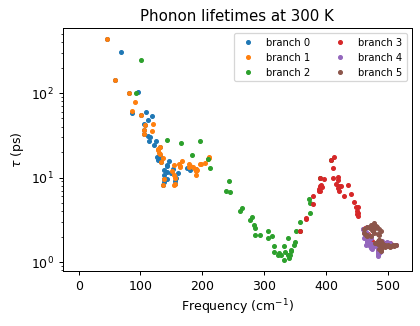

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.5))
for j in range(ns):
    ax.semilogy(omega[:, j], tau[:, j, it300], "o", ms=3, label=f"branch {j}")
ax.set_xlabel(r"Frequency (cm$^{-1}$)")
ax.set_ylabel(r"$\tau$ (ps)")
ax.set_title(f"Phonon lifetimes at {temps[it300]:.0f} K")
ax.legend(fontsize=8, ncol=2)
plt.show()

## 4. Rebuilding $\kappa$ from the mode sum

In the relaxation-time approximation *anphon* evaluates (`anphon/conductivity.cpp`)

$$
\kappa_{\mu\nu}(T) = \frac{1}{N V} \sum_{\mathbf{k} j} C_{\mathbf{k}j}(T)\, v^\mu_{\mathbf{k}j} v^\nu_{\mathbf{k}j}\, \tau_{\mathbf{k}j}(T),
$$

where $N$ is the number of $k$ points of the full mesh and $V$ the volume of the primitive cell.
$C$ and $\tau$ are the same for all $k$ points in a star, so the sum runs over the irreducible points
with $v^\mu v^\nu$ summed over the star.

At degenerate modes the velocity of a single branch depends on the (arbitrary) choice of eigenvectors.
*anphon* therefore uses the **velocity diad** $W^{\mu\nu}_{\mathbf{k}j}$ (`velocity_diad`),
built from the velocity matrix inside each degenerate block, whose sum over the block does not depend on that choice.
For a non-degenerate mode it equals $v^\mu v^\nu$.

In [7]:
volume_m3 = f["metadata/PrimitiveCell/volume"][()] * (Bohr_in_Angstrom * 1.0e-10) ** 3

def star_sum(per_full_k):
    '''Sum a full-mesh array over the star of each irreducible k point.'''
    return np.add.reduceat(per_full_k, offsets[:-1], axis=0)

W = star_sum(diad)                                          # (nk, ns, 3, 3)
VV = star_sum(np.einsum("kja,kjb->kjab", vel, vel))         # plain v x v

def kappa_modes(it, vv=W):
    '''Mode-resolved kappa (nk, ns, 3, 3) in W/mK at temperature index it.'''
    C = heat_capacity(omega, temps[it])                     # J/K
    return (C * tau[:, :, it] * 1.0e-12)[:, :, None, None] * vv / (nk_full * volume_m3)

kappa_nb = np.array([kappa_modes(it).sum(axis=(0, 1)) for it in range(len(temps))])
kappa_vv = np.array([kappa_modes(it, VV).sum(axis=(0, 1)) for it in range(len(temps))])

rel = np.abs(kappa_nb - kappa_file).max(axis=(1, 2)) / np.abs(kappa_file).max(axis=(1, 2))
print(" T (K)   file xx     notebook xx   max rel. diff   plain v x v xx")
for it, T in enumerate(temps):
    print(f"{T:6.0f} {kappa_file[it,0,0]:11.4f} {kappa_nb[it,0,0]:13.4f} {rel[it]:14.2e} {kappa_vv[it,0,0]:14.4f}")

assert rel.max() < 1.0e-6, rel.max()

 T (K)   file xx     notebook xx   max rel. diff   plain v x v xx
   100    554.4988      554.4988       1.23e-15       547.7467
   150    273.9574      273.9574       8.30e-16       270.7582
   200    176.7118      176.7118       6.43e-16       174.5514
   250    131.0592      131.0592       6.51e-16       129.3677
   300    104.8422      104.8422       5.42e-16       103.4275
   350     87.7656       87.7656       3.24e-16        86.5402
   400     75.6927       75.6927       7.51e-16        74.6081
   450     66.6640       66.6640       4.26e-16        65.6894
   500     59.6329       59.6329       7.15e-16        58.7472
   550     53.9884       53.9884       2.63e-16        53.1764
   600     49.3489       49.3489       1.01e-15        48.5989
   650     45.4626       45.4626       3.13e-16        44.7658
   700     42.1566       42.1566       3.37e-16        41.5059
   750     39.3080       39.3080       5.42e-16        38.6976
   800     36.8264       36.8264       2.32e-15     

The mode sum with the velocity diad reproduces `kappa_peierls` to rounding precision.
The plain $v \otimes v$ of the stored branch velocities (last column) is about 1% lower:
at degenerate modes the per-branch velocities belong to one arbitrary choice of eigenvectors
and miss the off-diagonal velocity-matrix elements inside the degenerate block that the diad includes.

## 5. Mode-resolved analysis at 300 K

The mean free path of a mode is $\Lambda = |v|\,\tau$, with the speed $|v| = \sqrt{\mathrm{Tr}\,W}$ of the
irreducible point (the same definition as `analyzer.py --calc cumulative`).
We use the isotropic average $\kappa = \mathrm{Tr}\,\kappa/3$.

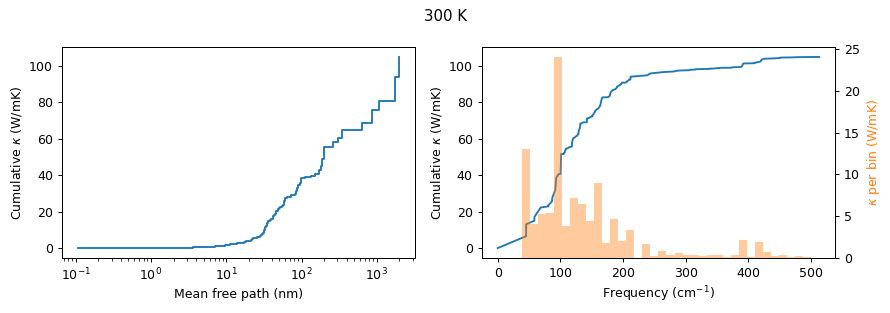

total kappa = 104.842 W/mK; half of it comes from modes with MFP < 200 nm
  branch 0:   28.901 W/mK
  branch 1:   36.573 W/mK
  branch 2:   33.893 W/mK
  branch 3:    5.256 W/mK
  branch 4:    0.110 W/mK
  branch 5:    0.109 W/mK


In [8]:
km = kappa_modes(it300)                                     # (nk, ns, 3, 3)
k_iso = np.trace(km, axis1=2, axis2=3) / 3.0                # (nk, ns)
speed = np.sqrt(np.maximum(np.trace(diad[offsets[:-1]], axis1=2, axis2=3), 0.0))   # m/s
mfp_nm = speed * tau[:, :, it300] * 1.0e-3                  # (m/s) * ps -> nm

order = np.argsort(mfp_nm.ravel())
mfp_sorted = mfp_nm.ravel()[order]
cum_mfp = np.cumsum(k_iso.ravel()[order])

order_w = np.argsort(omega.ravel())
cum_w = np.cumsum(k_iso.ravel()[order_w])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
ax = axes[0]
sel = mfp_sorted > 0.1      # hide the zone-center optical modes with (almost) zero speed
ax.semilogx(mfp_sorted[sel], cum_mfp[sel], drawstyle="steps-post")
ax.set_xlabel("Mean free path (nm)")
ax.set_ylabel(r"Cumulative $\kappa$ (W/mK)")
ax = axes[1]
ax.plot(omega.ravel()[order_w], cum_w, label="cumulative")
ax.set_xlabel(r"Frequency (cm$^{-1}$)")
ax.set_ylabel(r"Cumulative $\kappa$ (W/mK)")
ax2 = ax.twinx()
ax2.hist(omega.ravel(), bins=40, weights=k_iso.ravel(), color="C1", alpha=0.4)
ax2.set_ylabel(r"$\kappa$ per bin (W/mK)", color="C1")
fig.suptitle(f"{temps[it300]:.0f} K")
fig.tight_layout()
plt.show()

half = mfp_sorted[np.searchsorted(cum_mfp, 0.5 * cum_mfp[-1])]
print(f"total kappa = {cum_mfp[-1]:.3f} W/mK; half of it comes from modes with MFP < {half:.0f} nm")
for j in range(ns):
    print(f"  branch {j}: {k_iso[:, j].sum():8.3f} W/mK")

The branches are numbered in ascending frequency at each $k$ point (0–2 are acoustic).
On this coarse $10\times10\times10$ mesh the curves are steppy;
a denser mesh smooths them and changes $\kappa$ by a few percent.

### Cross-check with `analyzer.py`

In a local checkout, `tools/analyzer.py --calc cumulative` gives the cumulative $\kappa$ on a grid of lengths $L$
(all modes with $\Lambda \le L$). We evaluate our mode data on the same grid.

In [9]:
import subprocess
import sys

analyzer = os.path.join("..", "..", "tools", "analyzer.py")
if os.path.exists(analyzer):
    out = subprocess.run([sys.executable, analyzer, "--calc", "cumulative", "--temp", f"{temps[it300]:g}",
                          "--h5", path, "--nsample", "50"],
                         capture_output=True, text=True, check=True).stdout
    ref = np.loadtxt(out.splitlines())                      # L (nm), xx, yy, zz
    ours = np.array([km[mfp_nm <= L].sum(axis=0).diagonal() for L in ref[:, 0]])
    # analyzer prints three decimals
    print("max |difference| (W/mK):", np.abs(ours - ref[:, 1:]).max())
    print("analyzer at the largest L:", ref[-1, 1:], " notebook:", ours[-1])
else:
    print("tools/analyzer.py not found (not a local checkout); skipped.")

max |difference| (W/mK): 0.0004958424615608692
analyzer at the largest L: [104.842 104.842 104.842]  notebook: [104.84216229 104.84216229 104.84216229]


In [10]:
f.close()